In [1]:
from models.models import HierarchicalPanelICA

from pathlib import Path
import joblib

import matplotlib.pyplot as plt
import numpy as np

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
layer3_model_path = data_basepath / "layer3_models/layer3_340.joblib"
layer2_models_path = data_basepath / "layer2_models"

layer3_model = joblib.load(layer3_model_path)
print("layer3_model", layer3_model)
print("layer3 n_components", layer3_model.n_components)
layer3_model_mixing = layer3_model.mixing_

layer2_model_list = []
print("Loading layer 2 models")
for entry in layer2_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        layer2_model_list.append(model)
        print(model)

n_patch_components = model.components_.shape[0]
print("n_components", n_patch_components)
n_patch_pixels = model.components_.shape[1]
print("n_patch_pixels", n_patch_pixels)


layer3_model FastICA(n_components=340, random_state=42, whiten='unit-variance')
layer3 n_components 340
Loading layer 2 models
FastICA(n_components=40, random_state=752767290, whiten='unit-variance')
FastICA(n_components=40, random_state=3653403230, whiten='unit-variance')
FastICA(n_components=40, random_state=70985653, whiten='unit-variance')
FastICA(n_components=40, random_state=323153948, whiten='unit-variance')
FastICA(n_components=40, random_state=1322117303, whiten='unit-variance')
FastICA(n_components=40, random_state=2195314464, whiten='unit-variance')
FastICA(n_components=40, random_state=2735729614, whiten='unit-variance')
FastICA(n_components=40, random_state=175979944, whiten='unit-variance')
FastICA(n_components=40, random_state=1158725111, whiten='unit-variance')
n_components 40
n_patch_pixels 144


In [3]:
hmodel = HierarchicalPanelICA(
    G_X_model=layer3_model,
    X_sigma=0.1,
    X_I_models=layer2_model_list,
    I_sigma=0.1,
)

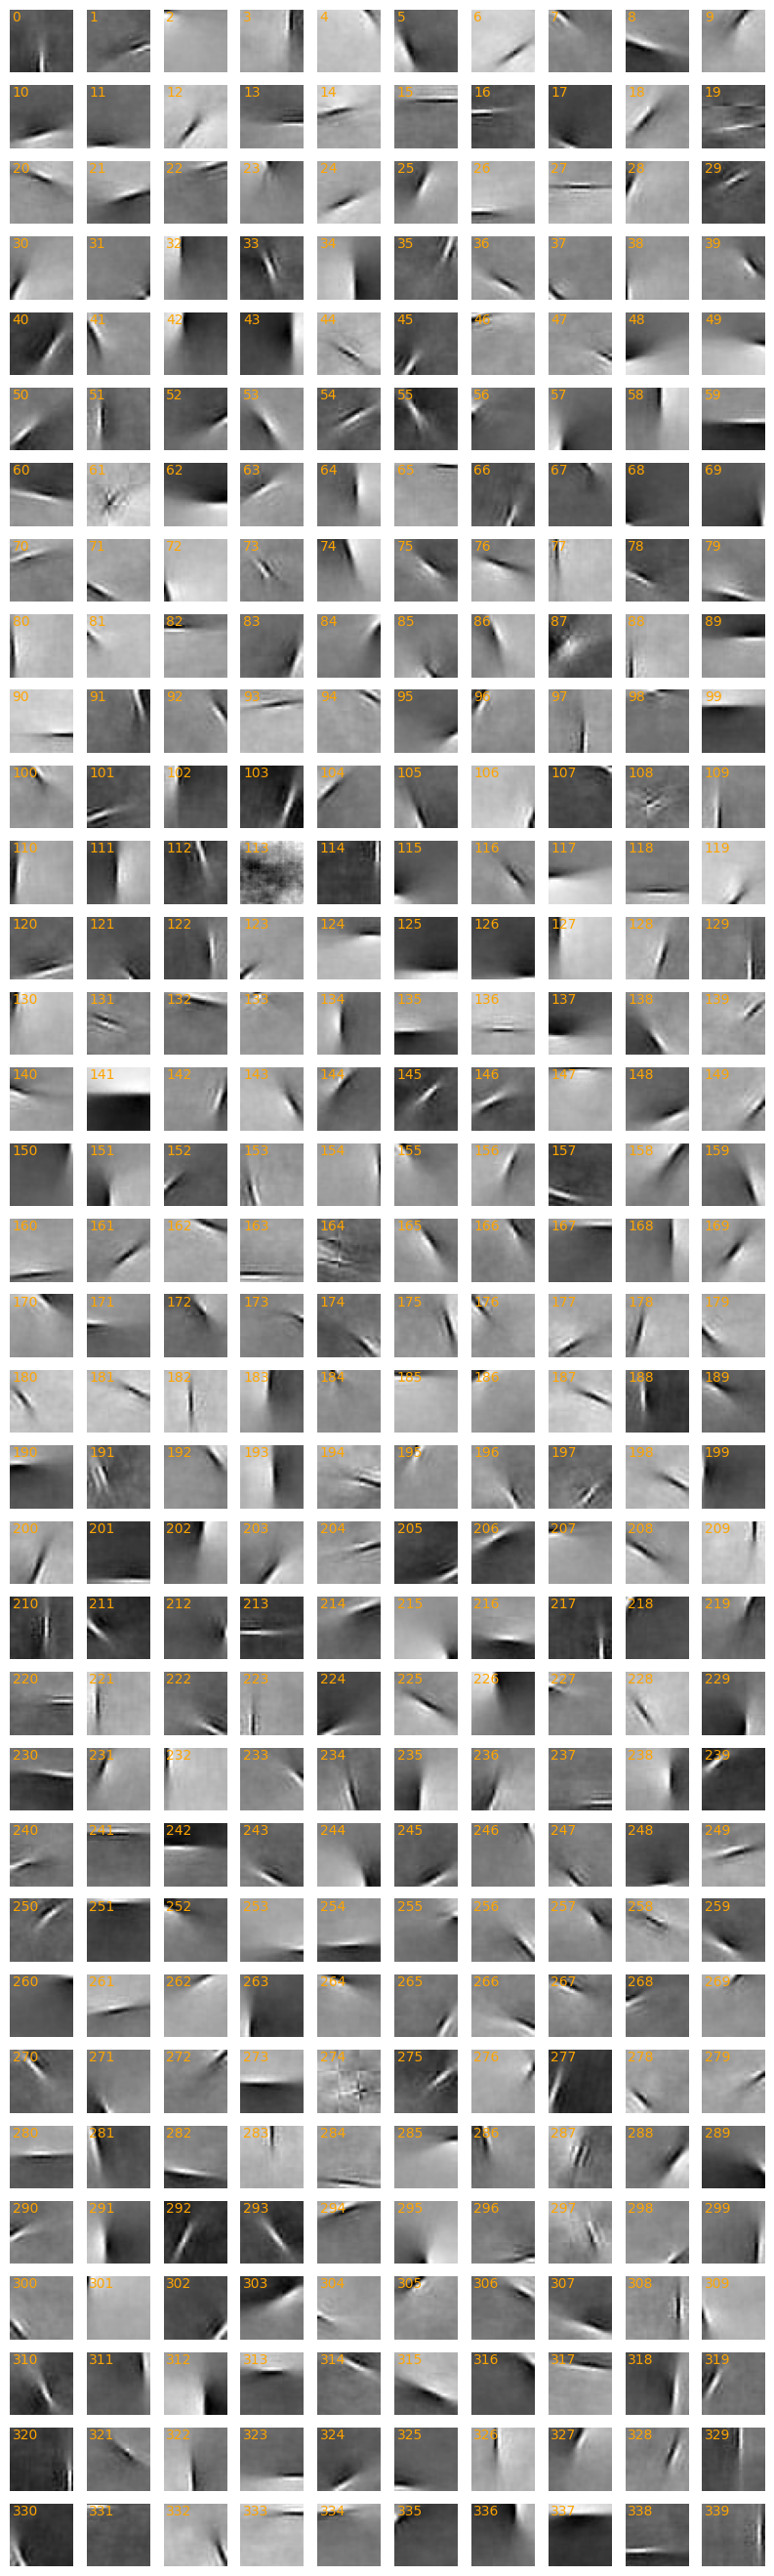

In [4]:
hmodel.visualize_learned_G()

generated_Is (340, 9, 12, 12)
generated_Is (340, 36, 36)


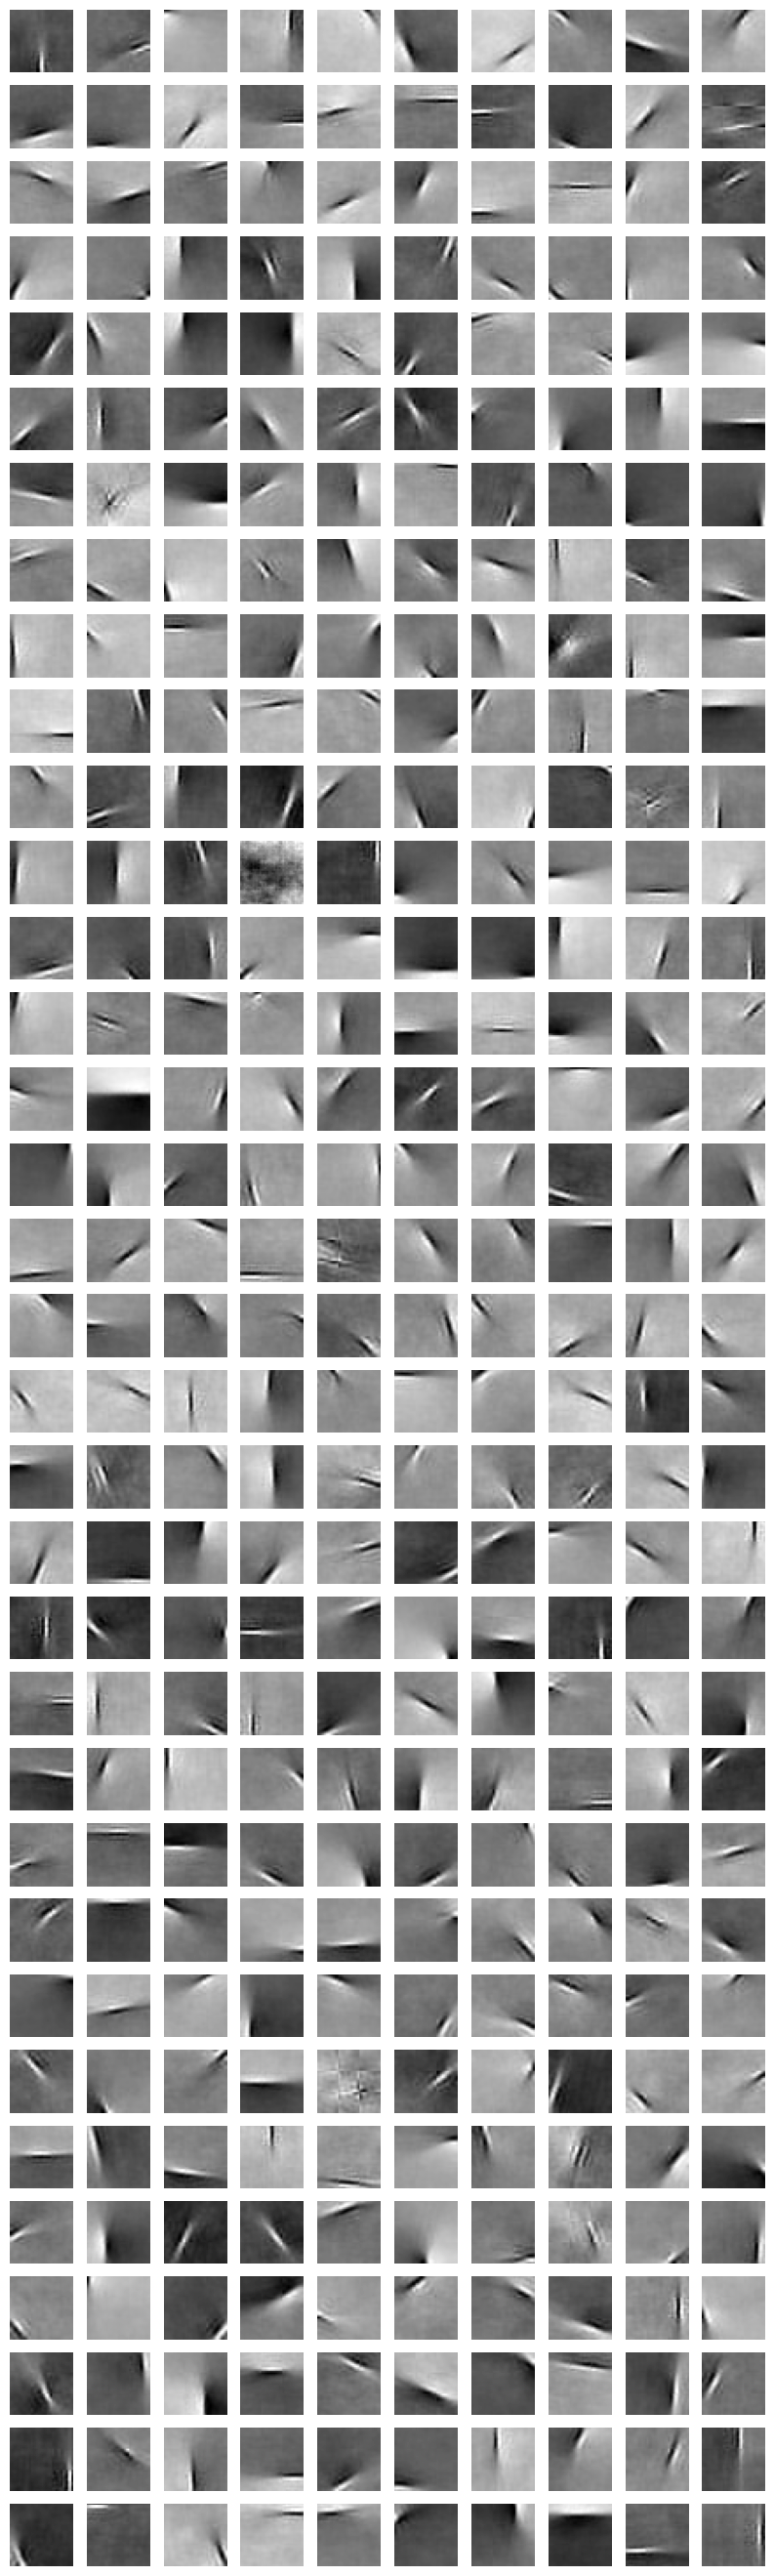

In [19]:
generated_Is = []
G_dim = layer3_model.n_components
for hot_idx in range(G_dim):
    G = np.zeros(G_dim)
    G[hot_idx] = 1
    G = G.reshape(1, -1)
    # X = layer3_model.inverse_transform(G)
    X = G @ layer3_model.mixing_.T
    X_patches = X.reshape(1, 9, 40).transpose(1, 0, 2)
    I_patches = []
    for X_patch, layer2_model in zip(X_patches, layer2_model_list):
        # I_patch = layer2_model.inverse_transform(X_patch)
        I_patch = X_patch @ layer2_model.mixing_.T
        I_patch = I_patch.squeeze(0).reshape(12, 12)
        I_patches.append(I_patch)
    I_patches = np.array(I_patches)
    generated_Is.append(I_patches)
generated_Is = np.array(generated_Is)
print("generated_Is", generated_Is.shape)
generated_Is = np.array(
    [
        np.vstack(
            [
                np.hstack(I[i * 3 : (i + 1) * 3]) for i in range(3)
            ]
        ) for I in generated_Is
    ]
)
print("generated_Is", generated_Is.shape)

nrows = int(generated_Is.shape[0]/10)
ncols = 10
# vmin = -np.max(np.abs(generated_Is))
# vmax = np.max(np.abs(generated_Is))
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
for idx, ax in enumerate(ax.flatten()):
    ax.imshow(generated_Is[idx], cmap="gray")
    ax.axis("off")